1. This notebook sets up the necessary libraries and environment for a MIMO detection. At present, we use CDL channel with 16qam modulation. The LMMSE equalizer is used as a tentative baseline for comparison.


2. Simple Model comprises n  PGDnet layers (delta and damping factors are the only 2 parameters in each layer)

3. The Projected Gradient Descent (PGD) method with boundary box projection requires approximately 20 iterations to achieve a Symbol Error Rate (SER) below 25%, matching the LMMSE baseline. For PGDNet, using 20 or more DetNet layers is recommended to attain a non-ML SER of around 20%.

4. Note: The noise variance of the additive white Gaussian noise (AWGN) is fixed at 0.25 during the MIMO system simulation, setting a specific SNR level. Varying the noise variance is avoided to simplify the CDL channel simulation and focus on evaluating detector performance under consistent conditions.

------ y and h are generated on-the-go based on the count of steps

------ rx = 8; tx = 4; h = (8,4)  --> 1 sample

------ step = 1 iteration of training loop done on one batch


# Libraries

## In case you want to utilise the GPU in SSH Project

In [1]:
# gpus = tf.config.list_physical_devices('GPU')
# print('Number of GPUs available :', len(gpus))
# if gpus:
#     gpu_num = 0 # Number of the GPU to be used
#     try:
#         # tf.config.set_visible_devices(gpus[gpu_num], 'GPU')
#         # tf.config.set_visible_devices([], 'GPU')
#         print('Only GPU number', gpu_num, 'used.')
#         # tf.config.experimental.set_memory_growth(gpus[gpu_num], True)
#         # tf.config.experimental.set_virtual_device_configuration(gpus[gpu_num], [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1024)])
#         tf.config.set_logical_device_configuration(gpus[gpu_num], [tf.config.LogicalDeviceConfiguration(memory_limit=1024)])
#         # logical_gpus = tf.config.experimental.list_logical_devices('GPU')
#         logical_gpus = tf.config.list_logical_devices('GPU')
#         print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
#     except RuntimeError as e:
#         print(e)


In [2]:
# %pip install sionna -U -q

In [3]:
## To configure CPU / GPU usage, suppress Tensorflow warnings, Install Sionna and set a reproducible seed

import os
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

# Set random seed for reproducability
sionna.phy.config.seed = 42

In [4]:
import os
import sys
import tensorflow as tf

import numpy as np  ## Computations
from sionna.phy import Block  ## Base class for physical layer components
from sionna.phy.utils import compute_ser  ## Utility to compute Symbol Error Rate (SER)
# from sionna.phy.channel import FlatFadingChannel,  KroneckerModel  ## Rayleigh Flat-Fading Channel Model
from sionna.phy.channel.utils import exp_corr_mat  ## Exponential correlation matrics (based on antenna distance)
from sionna.phy.mimo import lmmse_equalizer  ## LLMSE Equaliser (Could be a baseline for Projective Gradient Descent Method Comparison)
from sionna.phy.mapping import SymbolDemapper, Mapper, QAMSource  ## QAM Symbol Mapping and Demapping Utilities

## Visualisation
%matplotlib inline
import matplotlib.pyplot as plt  ## For Static Plotting
import plotly.graph_objects as go  ## For Interactive Plotting
from plotly.subplots import make_subplots  ## Create Subplots in a single figure

from tqdm import tqdm  ## To track runtime progress

## Import libraries specifc to CDL Channel

In [5]:
from sionna.phy.mimo import StreamManagement  ## To handle multiple parallel data streams

from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, OFDMModulator, OFDMDemodulator, RZFPrecoder, RemoveNulledSubcarriers
# - ResourceGrid: defines the OFDM time–frequency grid (slots, subcarriers, pilots, etc.)
# - ResourceGridMapper: maps encoded symbols onto the grid (data + pilot placement)
# - LSChannelEstimator: least-squares channel estimation from pilot symbols
# - OFDMModulator: converts mapped symbols to time-domain OFDM waveforms (IFFT + CP)
# - OFDMDemodulator: inverse of above (removes CP + FFT back to frequency domain)
# - RZFPrecoder: regularized zero-forcing precoder for downlink multi-user MIMO
# - RemoveNulledSubcarriers: removes unused subcarriers (e.g., guard bands, DC)

from sionna.phy.channel.tr38901 import AntennaArray, CDL
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, cir_to_time_channel, time_lag_discrete_time_channel, ApplyOFDMChannel, ApplyTimeChannel, OFDMChannel, TimeChannel
# - subcarrier_frequencies: computes OFDM subcarrier frequencies
# - cir_to_ofdm_channel: converts channel impulse response (CIR) → OFDM domain channel
# - cir_to_time_channel: converts CIR → time-domain discrete channel taps
# - time_lag_discrete_time_channel: generates time-lagged discrete channel representation
# - ApplyOFDMChannel: applies channel directly in frequency domain
# - ApplyTimeChannel: applies channel in time domain
# - OFDMChannel: convenience wrapper for OFDM channel simulation
# - TimeChannel: convenience wrapper for time-domain channel simulation

from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder  # If not already present
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber

In [6]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Generating a sample CDL dataset

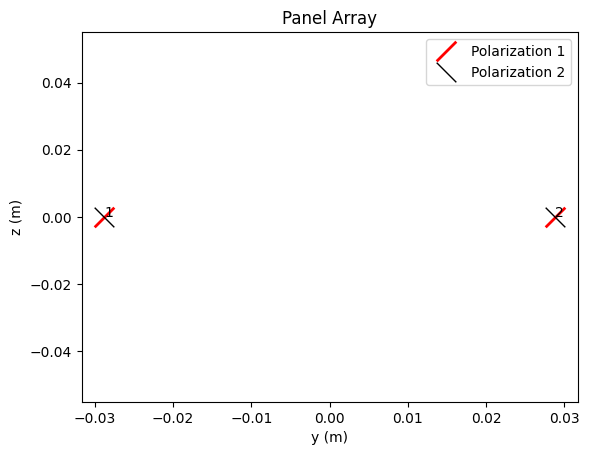

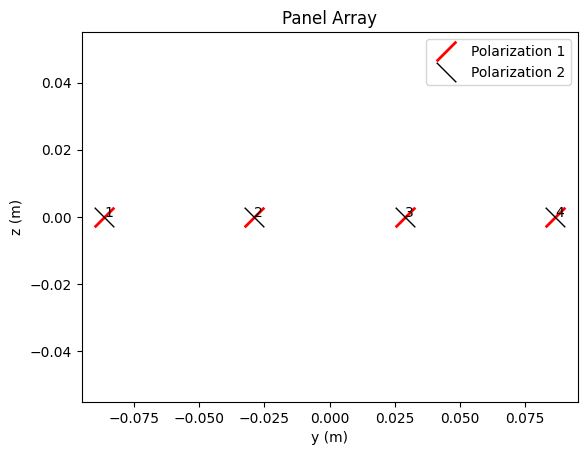

In [7]:
# Fixed parameters based on requirements
num_tx_ant = 4  # Example transmitter antennas; adjust as needed
num_rx_ant = 8  # 2x transmitter (or set to 16 for 4x)
sample_size = 500  # 500 channel realisations

num_bits_per_symbol = 4  # Keep for 16-QAM

carrier_frequency = 2.6e9  # Hz, as in tutorial
delay_spread = 300e-9  # Seconds, as in tutorial; adjust if needed
direction = "uplink"  # Or "downlink"
cdl_model = "B"  # Example from tutorial; choose A-E based on needs
speed = 10  # m/s, from tutorial

no = 0.25 ## scaling awgn during transmission

ut_array = AntennaArray(num_rows=1,
                        num_cols=int(num_tx_ant / 2),  # For dual polarization (cross, 2 parts)
                        polarization="dual",
                        polarization_type="cross",  # Cross-polarization (1,2, or 4 parts via num_cols)
                        antenna_pattern="38.901",  # Default
                        carrier_frequency=carrier_frequency)
bs_array = AntennaArray(num_rows=1,
                        num_cols=int(num_rx_ant / 2),
                        polarization="dual",
                        polarization_type="cross",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)


ut_array.show()
bs_array.show()

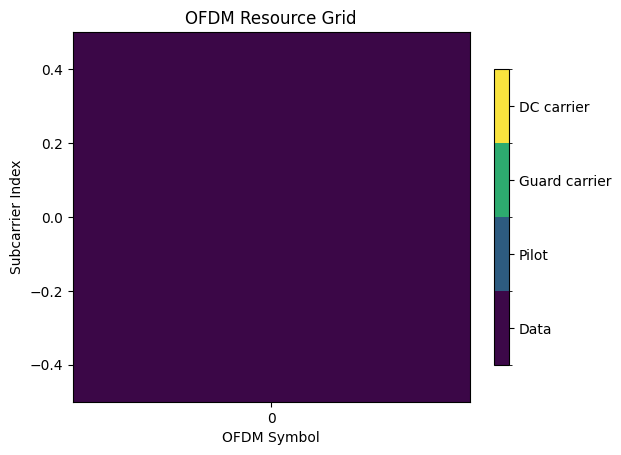

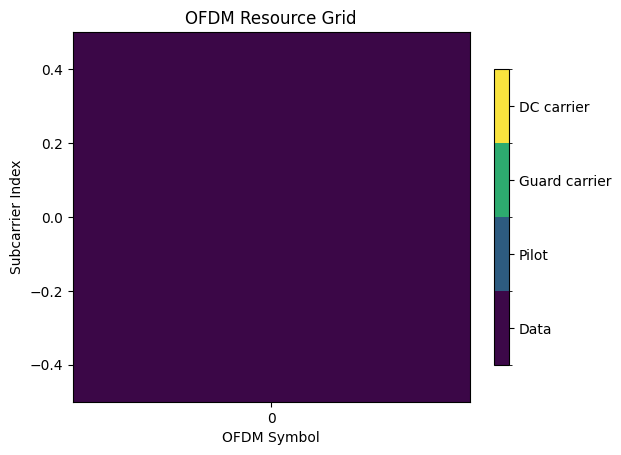

In [8]:
rg = ResourceGrid(  # Correct: Defines OFDM grid; minimal here for simplicity.
    num_ofdm_symbols=1,           # Number of OFDM symbols in the time domain (1 here)  # Single symbol: No time-varying.
    fft_size=1,                  # FFT size → number of subcarriers in frequency domain  # =1: Key simplification; flat-fading approx (no selectivity).
    subcarrier_spacing=15e3,       # Subcarrier spacing in Hz (15 kHz typical for LTE/5G)  # Standard; with fft_size=1, bandwidth=15kHz (narrowband).
    num_tx=1,                      # Number of transmit antennas (or antenna ports) used in grid  # =1: Treats UE as single "tx" with streams.
    num_streams_per_tx=num_tx_ant # Number of spatial streams per transmit antenna  # =4: MIMO layers = ants (full rank assumption).
)
rg.show()  # Good debug: Plots grid (pilots, guards—minimal here).

In [9]:
cdl = CDL(cdl_model, delay_spread, carrier_frequency, ut_array, bs_array, direction, min_speed=speed)  # Instantiates CDL with params; loads 3GPP tables for "B".

a, tau = cdl(batch_size=sample_size, num_time_steps=1, sampling_frequency=1/rg.ofdm_symbol_duration)  # Generates CIR; a (gains), tau (delays). sampling_freq from rg (high for small symbol duration)
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)  # [0] Hz since fft_size=1
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)  # Transforms to freq-domain; normalize for unit power. h ~ [500,1,8,1,4,1,1].

# Reshape h to desired dimension: [batch_size, 1 (num_ues), num_tx_ant, 1 (num_rx_base), num_rx_ant, 1 (time), 500 (freq)]
#h = tf.transpose(h_freq, [0, 3, 4, 1, 2, 5, 6])  # Adjust indices: original [bs, rx=1, rx_ant, tx=1, tx_ant, time=1, freq=500]

h =h_freq
print("Shape of h:", h.shape)  # Verify

# Generate QAM symbols
qam_source = QAMSource(num_bits_per_symbol)
x_symbols = qam_source([sample_size, num_tx_ant])  # shape: [batch, tx_ant] aka 500,4


# For fft_size=1, no need for complex tiling; reshape for ResourceGridMapper
# ResourceGrid expects [batch, num_tx=1, num_streams_per_tx=4, num_ofdm_symbols=1, fft_size=1]
x_mapped = tf.reshape(x_symbols, [sample_size, 1, num_tx_ant, 1, 1])  # [500, 1, 4, 1, 1]
print("Shape of x_mapped:", x_mapped.shape)
print("Sum of x_mapped:", tf.reduce_sum(tf.abs(x_mapped)).numpy())


# Simulate y using CDL channel
channel = ApplyOFDMChannel(add_awgn=True)
y = channel(x_mapped, h, no)  # [500, 1, 8, 1, 1]
print("Shape of y:", y.shape)
print("Sum of y:", tf.reduce_sum(tf.abs(y)).numpy())

# Squeeze for PGD compatibility (assuming flat-fading PGD)
h_squeezed = tf.squeeze(h, axis=[1, 3, 5, 6])  # [500, 8, 4]
y_squeezed = tf.squeeze(y, axis=[1, 3, 4])  # [500, 8]
x_squeezed = tf.squeeze(x_mapped, axis=[1, 3, 4])  # [500, 4]
print("Squeezed shapes for PGD: h", h_squeezed.shape, "y", y_squeezed.shape, "x", x_squeezed.shape)

Shape of h: (500, 1, 8, 1, 4, 1, 1)
Shape of x_mapped: (500, 1, 4, 1, 1)
Sum of x_mapped: 1893.7937
Shape of y: (500, 1, 8, 1, 1)
Sum of y: 7202.162
Squeezed shapes for PGD: h (500, 8, 4) y (500, 8) x (500, 4)


# Baselines

## LMMSE Equaliser on CDL

Effective Noise Variance (LMMSE): 0.12877844
Theoretical Estimated Noise Variance (LMMSE): 0.12824634
Symbol Error Rate (LMMSE): 0.2575


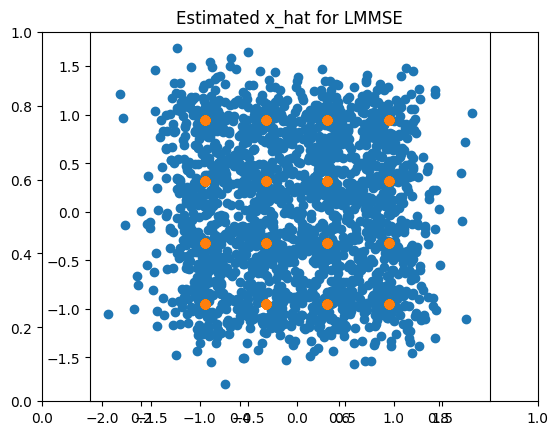

In [10]:
y = y_squeezed
h = h_squeezed
x = x_squeezed

symbol_demapper = SymbolDemapper("qam", num_bits_per_symbol, hard_out=True)  # QAM symbol demapper (hard decision) to map received signals back to symbol indices
x_ind = symbol_demapper(x, no)  # Get true transmitted symbol indices from original QAM symbols
s = tf.cast(no * tf.eye(num_rx_ant, num_rx_ant), y.dtype)  # Regularization matrix for LMMSE: s = σ_n² * I (noise variance times identity)

x_hat_lmmse, no_eff = lmmse_equalizer(y, h, s)   # Apply LMMSE equalizer to estimate transmitted symbols and get effective noise variance
x_ind_lmmse = symbol_demapper(x_hat_lmmse, no)  # Demap LMMSE-estimated symbols to indices

ser_lmmse = compute_ser(x_ind, x_ind_lmmse)  # Compute Symbol Error Rate (SER) between true and LMMSE-estimated symbols

noise_var_eff = np.var(x - x_hat_lmmse)  # Compute effective noise variance from LMMSE estimates
noise_var_est = np.mean(no_eff)           # Theoretical estimated noise variance

print("Effective Noise Variance (LMMSE):", noise_var_eff)  ## Just confirming the correctness of the LMMSE estimate
print("Theoretical Estimated Noise Variance (LMMSE):", noise_var_est)
print("Symbol Error Rate (LMMSE):", ser_lmmse.numpy())  # SER achieved by LMMSE baseline


## Plotting Transmitted and Received Constellation
plt.title("Estimated x_hat for LMMSE")
plt.axes().set_aspect(1.0)
plt.scatter(np.real(x_hat_lmmse), np.imag(x_hat_lmmse));
plt.scatter(np.real(x), np.imag(x));

## Maximum Likelihood Detector SER ~15.35%

In [11]:
# Maximum Likelihood Detector
from sionna.phy.mimo import MaximumLikelihoodDetector

# Instantiate ML detector
ml_detector = MaximumLikelihoodDetector(
    output="symbol",
    demapping_method="app",
    num_streams=num_tx_ant,
    constellation_type="qam",
    num_bits_per_symbol=num_bits_per_symbol,
    constellation = None,
    hard_out=True
)

In [12]:
# Apply ML detector
x_ind_ml = ml_detector(y, h, s)  # Output: [batch_size, num_tx_ant]
ser_ml = compute_ser(x_ind, x_ind_ml)  # Compare true indices (x_ind) with ML estimates

print("Symbol Error Rate (ML):", ser_ml.numpy())


## The Maximum Likelihood (ML) detector is theoretically optimal for uncoded MIMO systems under AWGN,
## It exhaustively searches all possible symbol combinations to minimize the SER, achieving the lowest possible error rate

Symbol Error Rate (ML): 0.148


## K-Best Detector ~15.5%

In [13]:
from sionna.phy.mimo import KBestDetector

# Instantiate K-Best detector
kbest_detector = KBestDetector(
    output="symbol",
    num_streams=num_tx_ant,
    k=64,  # Number of candidates (adjust for trade-off between performance and complexity)
    constellation_type="qam",
    num_bits_per_symbol=num_bits_per_symbol,
    hard_out=True,
    use_real_rep=False
)

In [14]:
x_ind_kbest = kbest_detector(y_squeezed, h_squeezed, s)  # Output: [batch_size, num_tx_ant]
ser_kbest = compute_ser(x_ind, x_ind_kbest)  # Compare true indices (x_ind) with K-Best estimates

print("Symbol Error Rate (K-Best, k=64):", ser_kbest.numpy())

Symbol Error Rate (K-Best, k=64): 0.1575


# Auxiliary Mapper Function

In [15]:
# Define constellation_tensor globally
mapper = Mapper("qam", num_bits_per_symbol=4)  ## Initialize a Mapper for 16-QAM with specified bits per symbol
constellation = mapper.constellation.points.numpy() ## Extract the constellation points as a NumPy array
## Could not find the utility in Sionna that maps indices of QAM constellation to the corresponding complex numbers. Hence done manally. Verified the correctness
constellation_dict = {i: constellation[i] for i in range(16)}
constellation_tensor = tf.constant(list(constellation_dict.values()), dtype=tf.complex64)

@tf.function
def map_indices_to_complex(indices):
    """Maps integer indices to complex constellation points using tf.gather."""
    indices = tf.clip_by_value(indices, 0, 15)  # Ensure indices are within valid range [0, 15]
    mapped_values = tf.gather(constellation_tensor, indices)  # Use global constellation_tensor
    return tf.reshape(mapped_values, tf.shape(indices))  # Reshape to maintain original shape


# ## Just checking the output of indices and corresponding constellation
# # print(x_ind_lmmse)

# # dummy_sample = map_indices_to_complex(x_ind_lmmse)
# # print("\n\n",dummy_sample)

# PGDNet Model

### Tensorflow libraries

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import time

### Boundary Box Projection

In [17]:
# @tf.function
def project_to_bbox(x_hat, damping_factor, min_val=-0.95, max_val=0.95):
    """
    Projects a complex tensor towards a bounding box using a damping factor. The final point is an interpolation between the original point (x_hat) and
    its fully projected version.
    """
    # Clip the real and imaginary parts to find the fully projected point
    real_part = tf.clip_by_value(tf.math.real(x_hat), min_val, max_val)
    imag_part = tf.clip_by_value(tf.math.imag(x_hat), min_val, max_val)
    x_projected = tf.complex(real_part, imag_part)

    # Cast damping_factor to complex64 to match x_hat and x_projected
    damping_factor_complex = tf.cast(damping_factor, tf.complex64)

    # Perform interpolation
    return (1.0 - damping_factor_complex) * x_hat + damping_factor_complex * x_projected

### Class for a single PGDNet Layer

In [18]:
## Implementing a single layer of the projected gradient descent algorithm

class ScalarMinMaxConstraint(tf.keras.constraints.Constraint):
    """Constrains a scalar to lie within [min_value, max_value]."""
    def __init__(self, min_value=0.0, max_value=1.0):
        self.min_value = min_value
        self.max_value = max_value

    def __call__(self, w):
        return tf.clip_by_value(w, self.min_value, self.max_value)

    def get_config(self):
        return {"min_value": self.min_value, "max_value": self.max_value}

class SimplePGDLayer(layers.Layer):  ##   A single customised layer is defined
    def __init__(self, **kwargs):
        super(SimplePGDLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.delta = self.add_weight(
            name='delta',
            shape=(),
            initializer=tf.keras.initializers.RandomUniform(minval=0.001, maxval=0.1),
            constraint=tf.keras.constraints.NonNeg(),
            trainable=True
        )
        self.damping_factor = self.add_weight(
            name='damping_factor',
            shape=(),
            initializer=tf.keras.initializers.Constant(1.0),
            constraint=ScalarMinMaxConstraint(min_value=0.0, max_value=1.0),
            trainable=True
        )

    def call(self, inputs):  ## To perform one step of projected gradient descent
        x_k, H_adj_y, H_HH = inputs  ## Just unpacking the inputs to separate entities

        H_HH_x = tf.squeeze(tf.matmul(H_HH, tf.expand_dims(x_k, -1)), -1)   ## Hessian term  sample_size, tx  (tx * rx with rx * tx  whole with tx * 1 = tx*1) => batch_size, tx, 1  ; expand x_k from sample_size, tx to sample. tx, 1

        gradient_term = H_adj_y - H_HH_x  ## This the negation of the gradient

        # gradient_term_real = tf.concat([tf.math.real(gradient_term), tf.math.imag(gradient_term)], axis=1)

        # 2. Perform the gradient descent update step.
        x_updated = x_k + self.delta * gradient_term

        # 3. Project the updated estimate onto the bounding box.
        x_k_plus_1 = project_to_bbox(x_updated, self.damping_factor)

        return x_k_plus_1

### Class for the PGDNet Model

In [19]:
# --- The Full PGDNet Model ---
class PGDNet(Model):
    """
    A deep model that unfolds the Projected Gradient Descent (PGD) algorithm for MIMO detection.
    The model consists of a sequence of SimplePGDLayer instances.
    """
    def __init__(self, num_tx_ant, num_layers=15, **kwargs):
        super(PGDNet, self).__init__(**kwargs)
        self.num_tx_ant = num_tx_ant
        self.num_layers = num_layers
        # Create a list of PGD layers, each with its own trainable 'delta'.
        self.pgd_layers = [SimplePGDLayer(name=f'pgd_layer_{i}') for i in range(num_layers)]

    def call(self, inputs):
        h, y = inputs
        sample_size = tf.shape(h)[0]

        # Pre-calculate terms that are constant across layers
        H_adj = tf.linalg.adjoint(h)
        H_adj_y = tf.squeeze(tf.matmul(H_adj, tf.expand_dims(y, -1)), -1)
        H_HH = tf.matmul(H_adj, h)

        # Initialize symbol estimates with zeros
        x_k = tf.zeros([sample_size, self.num_tx_ant], dtype=tf.complex64)

        all_x_hats = [] # Store estimates from each layer for the loss function

        # The unfolding loop
        for layer in self.pgd_layers:
            x_k = layer((x_k, H_adj_y, H_HH))
            all_x_hats.append(x_k)

        return all_x_hats

    # Add this method
    def get_config(self):
        config = super(PGDNet, self).get_config()
        config.update({
            "num_tx_ant": self.num_tx_ant,
            "num_layers": self.num_layers,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

### Data Generation Pipeline

In [20]:
def cdl_generator(batch_size, num_tx_ant, num_rx_ant, num_bits_per_symbol, no=0.25, speed=10.0):
    """
    Fixed generator that properly handles CDL channel generation.
    """
    # Initialize Sionna components
    carrier_frequency = 2.6e9
    delay_spread = 300e-9
    direction = "uplink"
    cdl_model = "B"

    ut_array = AntennaArray(
        num_rows=1,
        num_cols=int(num_tx_ant / 2),
        polarization="dual",
        polarization_type="cross",
        antenna_pattern="38.901",
        carrier_frequency=carrier_frequency
    )
    bs_array = AntennaArray(
        num_rows=1,
        num_cols=int(num_rx_ant / 2),
        polarization="dual",
        polarization_type="cross",
        antenna_pattern="38.901",
        carrier_frequency=carrier_frequency
    )
    rg = ResourceGrid(
        num_ofdm_symbols=1,
        fft_size=1,
        subcarrier_spacing=15e3,
        num_tx=1,
        num_streams_per_tx=num_tx_ant
    )

    qam_source = QAMSource(num_bits_per_symbol)
    channel_sim = ApplyOFDMChannel(add_awgn=True)
    frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)

    while True:
        try:
            # Create a new CDL instance for each batch with randomized speed
            random_speed = np.random.uniform(10.0, 30.0)  # Use numpy instead of tf.random
            cdl = CDL(
                cdl_model,
                delay_spread,
                carrier_frequency,
                ut_array,
                bs_array,
                direction,
                min_speed=float(random_speed),  # Convert to Python float
                max_speed=float(random_speed)
            )

            # Generate channel
            a, tau = cdl(
                batch_size=batch_size,
                num_time_steps=1,
                sampling_frequency=1/rg.ofdm_symbol_duration
            )

            # Convert to frequency domain
            h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)

            # Ensure proper shape before reshaping
            h_freq = tf.ensure_shape(h_freq, [batch_size, 1, num_rx_ant, 1, num_tx_ant, 1, 1])


            # Generate QAM symbols
            x_symbols = qam_source([batch_size, num_tx_ant])
            x_mapped = tf.reshape(x_symbols, [batch_size, 1, num_tx_ant, 1, 1])

            # Apply channel
            y = channel_sim(x_mapped, h_freq, no)

            # Reshape for output - use tf.reshape instead of squeeze to maintain batch dimension
            h_squeezed = tf.reshape(h_freq, [batch_size, num_rx_ant, num_tx_ant])
            y_squeezed = tf.reshape(y, [batch_size, num_rx_ant])
            x_squeezed = tf.reshape(x_symbols, [batch_size, num_tx_ant])

            # Verify shapes before yielding
            tf.debugging.assert_shapes([
                (h_squeezed, (batch_size, num_rx_ant, num_tx_ant)),
                (y_squeezed, (batch_size, num_rx_ant)),
                (x_squeezed, (batch_size, num_tx_ant))
            ])

            yield (h_squeezed, y_squeezed), x_squeezed

        except tf.errors.InvalidArgumentError as e:
            # If shape error occurs, skip this iteration and try again
            print(f"Warning: Skipping batch due to shape error: {e}")
            continue
        except Exception as e:
            print(f"Error in generator: {e}")
            raise





### Model and Data Parameters

In [21]:
# Model and Data Parameters
NUM_TX_ANT = 4
NUM_RX_ANT = 8
NUM_BITS_PER_SYMBOL = 4 # 16-QAM

# Training Hyperparameters
BATCH_SIZE = 512
TOTAL_TRAINING_STEPS = 200
VALIDATION_STEPS = 25 # How many batches to use for validation
VALIDATION_FREQUENCY = 40  # Validate every 10 steps

## Fixing the noise variance for CDL
FIXED_NO = 0.25


# Define the output signature for the generator
output_signature = (
    (tf.TensorSpec(shape=(None, NUM_RX_ANT, NUM_TX_ANT), dtype=tf.complex64),
     tf.TensorSpec(shape=(None, NUM_RX_ANT), dtype=tf.complex64)),
    tf.TensorSpec(shape=(None, NUM_TX_ANT), dtype=tf.complex64)
)


# For training and validation, set randomize_speed_per_batch=True
train_dataset = tf.data.Dataset.from_generator(
    lambda: cdl_generator(BATCH_SIZE, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=FIXED_NO),
    output_signature=output_signature
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: cdl_generator(BATCH_SIZE, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=FIXED_NO),
    output_signature=output_signature
)


# Prefetch for performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

### Loss Function

In [22]:
def detnet_loss(x_true, x_pred_list, h, y, num_bits_per_symbol, no, constellation_tensor):
    """
    Loss function: sum_k log(k+2) * ||x - x_hat_k||_2^2 / ||x - x_zf||_2^2
    x_true: True symbols [batch, num_tx_ant]
    x_pred_list: List of predicted symbols [L, batch, num_tx_ant]
    h: Channel matrix [batch, num_rx_ant, num_tx_ant]
    y: Received signal [batch, num_rx_ant]
    """
    # Compute Zero-Forcing (ZF) estimate
    h_t = tf.linalg.adjoint(h)  # [batch, num_tx_ant, num_rx_ant]
    hth = tf.matmul(h_t, h)  # [batch, num_tx_ant, num_tx_ant]
    hth_inv = tf.linalg.inv(hth + 1e-10 * tf.eye(NUM_TX_ANT, dtype=tf.complex64))  # Add small regularization
    y_exp = tf.expand_dims(y, -1)  # [batch, num_rx_ant, 1]
    x_zf = tf.squeeze(tf.matmul(tf.matmul(hth_inv, h_t), y_exp), -1)  # [batch, num_tx_ant]

    # Compute ZF error: ||x - x_zf||_2^2, averaged over antennas
    zf_error = tf.reduce_mean(tf.square(tf.abs(x_true - x_zf)), axis=1)  # [batch]
    zf_error = tf.maximum(zf_error, 1e-9)  # Avoid division by zero

    total_loss = 0.0
    for k, x_hat_k in enumerate(x_pred_list, start=1):
        # Compute layer error: ||x - x_hat_k||_2^2, averaged over antennas
        layer_error = tf.reduce_mean(tf.square(tf.abs(x_true - x_hat_k)), axis=1)  # [batch]
        # Normalize error
        normalized_error = layer_error / zf_error  # [batch]
        # Weight with log(k+2)
        weight = tf.math.log(tf.cast(k + 2, tf.float32))  # Avoid log(0) or log(1)
        weighted_error = weight * normalized_error
        total_loss += tf.reduce_mean(weighted_error)  # Scalar, averaged over batch

    return total_loss / len(x_pred_list)  # Normalize by number of layers

## Instantiating the Simplified Model


In [23]:
# Instantiate the simplified PGDNet model with 20 layers
simple_model = PGDNet(num_tx_ant=NUM_TX_ANT, num_layers=20)

# The optimizer can be chosen as before
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.012)

# from tensorflow.keras.optimizers import Lion
# optimizer = Lion(learning_rate=0.008)

symbol_demapper = SymbolDemapper("qam", NUM_BITS_PER_SYMBOL, hard_out=True)

**Tentative Count of Parameters**
= number of layers * 2  


### Creating a checkpoint object to save the model, optimizer and step counter

In [24]:
# Create a checkpoint object to save the model, optimizer, and step counter
## Feel free to tweak the directory
checkpoint_dir = './training_checkpoints_20_layers_008_Nadam_log_loss_512'
os.makedirs(checkpoint_dir, exist_ok=True)

# Step counter used in checkpoint (will be restored)
step_counter = tf.Variable(0, trainable=False, dtype=tf.int64)

# Create checkpoint and manager (save model + optimizer + step_counter)
checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=simple_model, step=step_counter)
manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=5)

# Try to restore latest checkpoint if available
if manager.latest_checkpoint:
    # use expect_partial() to avoid hard errors if you changed code; switch to assert_existing_objects_matched()
    checkpoint.restore(manager.latest_checkpoint).expect_partial()
    start_step = int(step_counter.numpy())
    print(f"Restored from {manager.latest_checkpoint}; resuming from step {start_step}")
else:
    start_step = 0
    print("No checkpoint found. Initializing from scratch.")

No checkpoint found. Initializing from scratch.


### Training and Evaluation Steps

In [25]:
@tf.function
def train_step(model, inputs, x_true):
    h, y = inputs
    # Assert shapes to ensure correctness
    tf.debugging.assert_shapes([
        (h, (None, NUM_RX_ANT, NUM_TX_ANT)),
        (y, (None, NUM_RX_ANT)),
        (x_true, (None, NUM_TX_ANT))
    ])
    with tf.GradientTape() as tape:
        x_pred_list = model(inputs, training=True)
        loss = detnet_loss(x_true, x_pred_list, h, y,
                           num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                           no=FIXED_NO,
                           constellation_tensor=constellation_tensor)
    grads = tape.gradient(loss, model.trainable_variables)
    # Check for None gradients
    if any(g is None for g in grads):
        raise ValueError("Found None gradients for some variables")
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, x_pred_list[-1]

@tf.function
def test_step(model, inputs, x_true):
    h, y = inputs
    x_pred_list = model(inputs, training=False)
    # Evaluate SER on the final layer's output
    x_pred_final = x_pred_list[-1]

    # Note: `no` is not available here, so we use a placeholder.
    # For a rigorous SER calculation, `no` should be passed or estimated.
    # We use 0.1 as a generic small value for demapping.
    x_ind_true = symbol_demapper(x_true, 0.1)
    x_hat_hard = symbol_demapper(x_pred_final, 0.1)
    ser = compute_ser(x_ind_true, x_hat_hard)
    return ser

### Training Loop

In [26]:
best_ser = float('inf')  # Initialize with infinity
best_checkpoint_dir = None

results_dir = os.path.join(os.getcwd(), "ML_Model")
os.makedirs(results_dir, exist_ok=True)

In [27]:
results_dir

'/content/ML_Model'

In [28]:
train_loss_history = []
val_ser_history = []
step_history = []


In [29]:
SAVE_EVERY = 50
TOTAL_TRAINING_STEPS = 400

In [30]:
import json

In [31]:
# Try to restore latest checkpoint if available
if manager.latest_checkpoint:
    # use expect_partial() to avoid hard errors if you changed code; switch to assert_existing_objects_matched()
    checkpoint.restore(manager.latest_checkpoint).expect_partial()
    start_step = int(step_counter.numpy())
    print(f"Restored from {manager.latest_checkpoint}; resuming from step {start_step}")
else:
    start_step = 0
    print("No checkpoint found. Initializing from scratch.")

# If start_step already >= TOTAL_TRAINING_STEPS, notify user
if start_step >= TOTAL_TRAINING_STEPS:
    print(f"Checkpoint step ({start_step}) >= TOTAL_TRAINING_STEPS ({TOTAL_TRAINING_STEPS}). "
          f"Set TOTAL_TRAINING_STEPS higher to continue training.")
else:
    # Number of additional steps to run
    steps_to_run = TOTAL_TRAINING_STEPS - start_step

    # Make sure iterators exist
    train_iterator = iter(train_dataset)
    pbar = tqdm(range(steps_to_run), desc="Training Progress")

    for _ in pbar:
        try:
            # Get next batch (recreate iterator automatically if it exhausts)
            try:
                inputs, x_true = next(train_iterator)
            except StopIteration:
                train_iterator = iter(train_dataset)
                inputs, x_true = next(train_iterator)
                _ = simple_model(inputs, training=False)

            # Perform one training step
            loss, _ = train_step(simple_model, inputs, x_true)
            train_loss_history.append(float(loss.numpy()))

            # Only increment and save step counter after a successful training step
            step_counter.assign_add(1)
            current_step = int(step_counter.numpy())

            # Update progress bar
            pbar.set_postfix({'loss': float(loss.numpy()), 'step': current_step})

            # Validation at your configured frequency
            if current_step % VALIDATION_FREQUENCY == 0:
                val_iterator = iter(val_dataset.take(VALIDATION_STEPS))
                total_ser = 0.0
                valid_batches = 0

                for _ in range(VALIDATION_STEPS):
                    try:
                        val_inputs, val_x_true = next(val_iterator)
                        ser = test_step(simple_model, val_inputs, val_x_true)
                        total_ser += ser
                        valid_batches += 1
                    except (StopIteration, tf.errors.InvalidArgumentError):
                        continue

                if valid_batches > 0:
                    avg_ser = (total_ser / valid_batches).numpy()
                    val_ser_history.append(avg_ser)
                    step_history.append(current_step)
                    print(f"\nStep {current_step}: Avg Validation SER = {avg_ser:.5f} ({valid_batches} valid batches)")

            # Periodically save a checkpoint (saves model + optimizer + step)
            if current_step % SAVE_EVERY == 0:
                ckpt_path = manager.save()
                print(f"Saved checkpoint at step {current_step}: {ckpt_path}")

        except tf.errors.InvalidArgumentError as e:
            # Skip bad batches but do NOT increment step_counter
            print(f"InvalidArgumentError at training step loop: {e}")
            continue
        except Exception as e:
            # For unexpected errors, print and re-raise after a few attempts if you want;
            # Here we re-raise so you can see the real error in interactive runs
            print(f"Unexpected error during training: {e}")
            raise

    # Save final checkpoint after finishing the run
    final_ckpt = manager.save()
    print(f"Final checkpoint saved: {final_ckpt}")

No checkpoint found. Initializing from scratch.


Training Progress:  10%|▉         | 39/400 [00:25<01:58,  3.05it/s, loss=3.19, step=40]

Condition x >= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[-1]

Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[1]
Condition x >= y did not hold.
First 1 elements of x:
[3]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[2]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x >= y did not hold.
First 1 elements of x:
[3]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First

Training Progress:  10%|█         | 42/400 [00:36<11:41,  1.96s/it, loss=3.24, step=42]


Step 40: Avg Validation SER = 0.22020 (25 valid batches)
Condition x >= y did not hold.
First 1 elements of x:
[3]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[1]


...

Training Progress: 100%|█████████▉| 399/400 [03:54<00:00,  2.43it/s, loss=2.79, step=400]

Condition x >= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[-1]
Condition x >= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[1]

Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[1]

Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[2]
Condition x >= y did not hold.
First 1 elements of x:
[3]
First 1 elements of y:
[0]
Condition x <= y did not hold.
First 1 elements of x:
[0]
First 1 elements of y:
[0]
Condition x >= y did not hold.
First 1 elements of x:
[3]
First 1 elements of y:
[0]
  (0) INVALID_ARGUMENT: {{function_node __wrapped__Greater_dev

Training Progress: 100%|██████████| 400/400 [04:13<00:00,  1.58it/s, loss=2.79, step=400]

Saved checkpoint at step 400: ./training_checkpoints_20_layers_008_Nadam_log_loss_512/ckpt-8


Final checkpoint saved: ./training_checkpoints_20_layers_008_Nadam_log_loss_512/ckpt-9


Choose a higher value for TOTAL_TRAINING_STEPS is you intend the train the model from the latest checkpoint!

In [ ]:
TOTAL_TRAINING_STEPS = 400

# Evaluation

### Plotting Training Curves

In [32]:
val_ser_history

[0.2201953125,
 0.21396484375,
 0.21341796875,
 0.21126953125,
 0.211171875,
 0.210625,
 0.20478515625,
 0.20953125,
 0.2094140625]

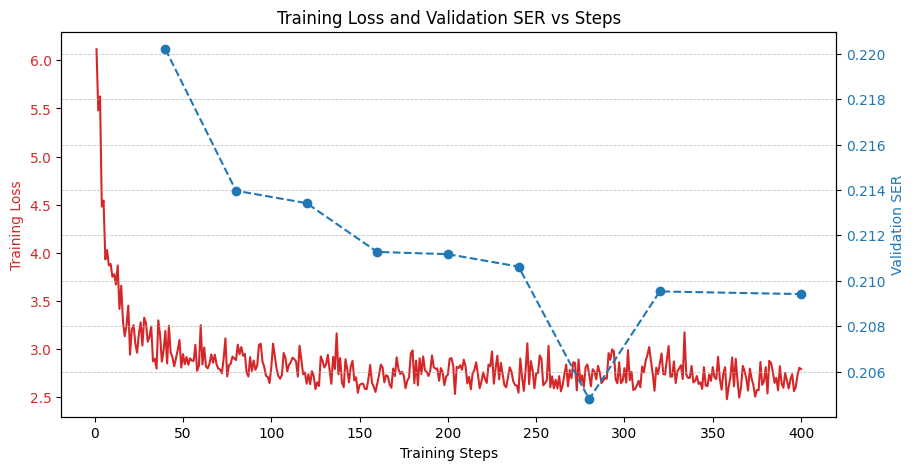

In [33]:
from matplotlib.ticker import FuncFormatter

def plot_training_curves(loss_history, ser_history, step_history):
    """Plots training loss (every step) and validation SER (sparse checkpoints)."""
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Training loss (dense curve)
    color = 'tab:red'
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Training Loss', color=color)
    ax1.plot(range(1, len(loss_history)+1), loss_history, color=color, label='Training Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    # Validation SER (sparse points)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Validation SER', color=color)
    ax2.plot(step_history, ser_history, color=color, marker='o', linestyle='--', label='Validation SER')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Training Loss and Validation SER vs Steps')
    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    plt.show()


# After the training loop finishes:
plot_training_curves(train_loss_history, val_ser_history, step_history)

In [34]:
import json

In [35]:
# Ensure these lists are defined and populated during training
train_loss_history.append(float(loss.numpy()))  # After loss, _ = train_step(simple_model, inputs, x_true)
val_ser_history.append(avg_ser)  # After avg_ser = (total_ser / valid_batches).numpy() in validation loop
json.dump({"step_history": step_history, "train_loss_history": train_loss_history, "val_ser_history": val_ser_history}, open("loss_history_10_LAYERS_008_Nadam_weighted_400steps_512_batch.json", "w"), indent=4)  # After training loop

In [36]:
def evaluate_ser(batch_size, no, speed, num_tx_ant=4, num_rx_ant=8, num_bits_per_symbol=4):
    """
    Evaluate SER for DetNet model and LMMSE equalizer with specified batch size, noise variance, and speed.
    """
    # Create a test dataset with specified batch size, noise variance, and speed
    test_dataset = tf.data.Dataset.from_generator(
        # ---- FIX: Correctly pass arguments to the generator ----
        lambda: cdl_generator(batch_size, num_tx_ant, num_rx_ant, num_bits_per_symbol, no=no, speed=speed),
        output_signature=(
            (tf.TensorSpec(shape=(None, num_rx_ant, num_tx_ant), dtype=tf.complex64),
             tf.TensorSpec(shape=(None, num_rx_ant), dtype=tf.complex64)),
            tf.TensorSpec(shape=(None, num_tx_ant), dtype=tf.complex64)
        )
    ).take(1).prefetch(tf.data.AUTOTUNE)

    # Initialize LMMSE equalizer components
    symbol_demapper = SymbolDemapper("qam", num_bits_per_symbol, hard_out=True)

    # Evaluate on the test dataset
    for inputs, x_true in test_dataset:
        h, y = inputs

        # DetNet evaluation
        x_pred_list = simple_model(inputs, training=False)
        x_pred_final = x_pred_list[-1]
        x_ind_true = symbol_demapper(x_true, 0.1)
        x_hat_hard = symbol_demapper(x_pred_final, 0.1)
        detnet_ser = compute_ser(x_ind_true, x_hat_hard)

        # LMMSE evaluation
        # Define s (noise covariance matrix) before using it
        s = tf.cast(no * tf.eye(num_rx_ant, dtype=tf.complex64), y.dtype)
        x_lmmse, _ = lmmse_equalizer(y, h, s)
        x_lmmse_ind = symbol_demapper(x_lmmse, 0.1)
        lmmse_ser = compute_ser(x_ind_true, x_lmmse_ind)

        # Print results
        print(f"\nEvaluation for Batch Size: {batch_size}, Noise Variance: {no}, Speed: {speed} m/s")
        print(f"DetNet SER: {detnet_ser:.5f}")
        print(f"LMMSE SER: {lmmse_ser:.5f}\n")

In [37]:
batch_size = 2000  # Example batch size
noise_variance = 0.25  # Example noise variance
speed = 15.0  # Example speed in m/s
evaluate_ser(batch_size, noise_variance, speed)




Evaluation for Batch Size: 2000, Noise Variance: 0.25, Speed: 15.0 m/s
DetNet SER: 0.21962
LMMSE SER: 0.26350



In [38]:
simple_model.summary()

Model: "pgd_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pgd_layer_0 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_1 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_2 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_3 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_4 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_5 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_6 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_7 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_8 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_9 (SimplePGDLayer)    │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_10 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_11 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_12 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_13 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_14 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_15 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_16 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_17 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_18 (SimplePGDLayer)   │ ?                      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pgd_layer_19 (SimplePGDLayer)   │ ?                      │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
simple_model.weights

[<Variable path=pgd_net/pgd_layer_0/delta, shape=(), dtype=float32, value=0.08029425889253616>,
 <Variable path=pgd_net/pgd_layer_0/damping_factor, shape=(), dtype=float32, value=0.8485444784164429>,
 <Variable path=pgd_net/pgd_layer_1/delta, shape=(), dtype=float32, value=0.04804786667227745>,
 <Variable path=pgd_net/pgd_layer_1/damping_factor, shape=(), dtype=float32, value=1.0>,
 <Variable path=pgd_net/pgd_layer_2/delta, shape=(), dtype=float32, value=0.4920229911804199>,
 <Variable path=pgd_net/pgd_layer_2/damping_factor, shape=(), dtype=float32, value=0.9653011560440063>,
 <Variable path=pgd_net/pgd_layer_3/delta, shape=(), dtype=float32, value=0.041864387691020966>,
 <Variable path=pgd_net/pgd_layer_3/damping_factor, shape=(), dtype=float32, value=0.2184356451034546>,
 <Variable path=pgd_net/pgd_layer_4/delta, shape=(), dtype=float32, value=0.18987242877483368>,
 <Variable path=pgd_net/pgd_layer_4/damping_factor, shape=(), dtype=float32, value=0.9230450391769409>,
 <Variable path

# Saving and loading a pre-trained model

In [ ]:
# Define results directory
results_dir = os.path.join(os.getcwd(), "ML_Model")

# Save the model as HDF5 (.h5) (Weughts)
simple_model.save(os.path.join(results_dir, 'PGDnet_10_layers_512_batch_012_lr_400_steps_adam_weighted.h5'))



In [ ]:
simple_model.summary()

In [ ]:
# Instantiate a new model
NUM_TX_ANT = 4  # Match your training setup
trained_simple_model = DetNet(num_tx_ant=NUM_TX_ANT, num_layers=13, hidden_dim=16)

# Build the model with dummy input shapes
# trained_simple_model.build([(None, 8, NUM_TX_ANT), (inputs, 8)])
trained_simple_model(inputs)

# Load weights from .h5 file
try:
    trained_simple_model.load_weights(os.path.join(results_dir, 'detnet_model_13_layers.h5'))
    print("Weights loaded successfully from .h5 file.")
except Exception as e:
    print(f"Error loading weights: {e}")
    raise

# Verify model parameters
trained_simple_model.summary()

In [ ]:
inputs[1]

In [ ]:
simple_model = trained_simple_model

In [ ]:
# Test predictions with evaluate_ser to confirm weights are loaded
print("Testing model predictions...")
evaluate_ser(batch_size=1024, no=0.25, speed=20.0)

# Combined Analysis

In [ ]:
import h5py
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
# Placeholder file paths (replace with your provided links)
json_files = {
    '5_Layers_Batch_512_LR_012': '/content/Z_Plot_Analysis/loss_history_5_LAYERS_008_adam_weighted_ce_500steps_512b.json',
    '10_Layers_Batch_512_LR_012': '/content/Z_Plot_Analysis/loss_history_10_LAYERS_008_Nadam_weighted_400steps_512_batch.json',
    '15_Layers_Batch_256_LR_008': '/content/Z_Plot_Analysis/loss_history_15_LAYERS_008_adam_weighted_ce_550steps.json',
    '20_Layers_Batch_256_LR_008': '/content/Z_Plot_Analysis/loss_history_20_LAYERS_008_Nadam_weighted_400steps_256_batch.json',
    '25_Layers_Batch_256_LR_008': '/content/Z_Plot_Analysis/loss_history_25_LAYERS_008_Nadam_weighted_500steps_256_batch.json',
    '30_Layers_Batch_512_LR_012': '/content/Z_Plot_Analysis/loss_history_30_LAYERS_008_adam_weighted_ce_500steps_512b.json'

}

h5_files = {
    '5_Layers_Batch_512_LR_012': '/content/Z_Plot_Analysis/PGDnet_5_layers_512_batch_012_lr_400_steps_adam_weighted.h5',
    '10_Layers_Batch_512_LR_012': '/content/Z_Plot_Analysis/PGDnet_10_layers_512_batch_012_lr_400_steps_adam_weighted.h5',
    '15_Layers_Batch_256_LR_008': '/content/Z_Plot_Analysis/PGDnet_15_layers_256_batch_008_lr_550_steps_adam_weighted_ce.h5',
    '20_Layers_Batch_256_LR_008': '/content/Z_Plot_Analysis/PGDnet_20_layers_256_batch_008_lr_400_steps_adam_weighted.h5',
    '25_Layers_Batch_256_LR_008': '/content/Z_Plot_Analysis/PGDnet_25_layers_256_batch_008_lr_500_steps_adam_weighted.h5',
    '30_Layers_Batch_512_LR_012': '/content/Z_Plot_Analysis/PGDnet_30_layers_512_batch_012_lr_500_steps_adam_weighted.h5'
}

# Colors for each model
colors = {
    '5_Layers_Batch_512_LR_012': 'purple',
    '10_Layers_Batch_512_LR_012': 'blue',
    '15_Layers_Batch_256_LR_008': 'green',
    '20_Layers_Batch_256_LR_008': 'yellow',
    '25_Layers_Batch_256_LR_008': 'orange',
    '30_Layers_Batch_512_LR_012': 'red'
}

In [ ]:
# Load data from JSON files
data = {}
for label, json_path in json_files.items():
    with open(json_path, 'r') as f:
        data[label] = json.load(f)


In [ ]:
# Plot 1: Loss vs. Steps
fig1 = go.Figure()
for label in json_files.keys():
    loss_history = data[label]['train_loss_history']
    steps = list(range(len(loss_history)))  # Assume loss recorded per step
    fig1.add_trace(go.Scatter(
        x=steps,
        y=loss_history,
        mode='lines',
        name=label,
        line=dict(color=colors[label])
    ))

fig1.update_layout(
    title='Training Loss vs. Steps',
    xaxis_title='Steps',
    yaxis_title='Loss',
    template='plotly',
    hovermode='closest'
)

# Plot 2: SER vs. Steps
fig2 = go.Figure()
for label in json_files.keys():
    step_history = data[label]['step_history']
    ser_history = data[label]['val_ser_history']
    fig2.add_trace(go.Scatter(
        x=step_history,
        y=ser_history,
        mode='lines+markers',
        name=label,
        line=dict(color=colors[label])
    ))

fig2.update_layout(
    title='Validation SER vs. Steps',
    xaxis_title='Steps',
    yaxis_title='SER',
    template='plotly',
    hovermode='closest'
)


# Save plots as HTML for interactivity
fig1.write_html('loss_vs_steps.html')
fig2.write_html('ser_vs_steps.html')

# Optionally display in Jupyter/Colab
fig1.show()
fig2.show()

In [ ]:
# !pip install kaleido plotly

import kaleido

In [ ]:
import h5py
import re

# --- Utility Function to Extract Layer Count from Filename ---
def get_layer_count(filename):
    """Extracts the number of layers (e.g., '20' from 'PGDnet_20_layers...')"""
    match = re.search(r'(\d+)_layers', filename)
    if match:
        return int(match.group(1))
    return 0


In [ ]:
weights = {}

# Define the definitive list of model prefixes to search:
# 1. 'pgd_net' (for the 15-layer file)
# 2. 'pgd_net_X' (for all others)
numerical_prefixes = [f'pgd_net_{i}' for i in range(16)] # Search up to pgd_net_15
net_prefixes_to_try = ['pgd_net'] + numerical_prefixes

In [ ]:
for label, h5_path in h5_files.items():
    deltas = []
    dampings = []

    # Dynamically determine the number of layers
    num_layers = get_layer_count(h5_path)

    if num_layers == 0:
        print(f"Warning: Could not determine layer count for {h5_path}.")
        weights[label] = {'deltas': deltas, 'dampings': dampings}
        continue

    try:
        with h5py.File(h5_path, 'r') as f:

            if 'model_weights' not in f:
                print(f"Error: 'model_weights' group not found at the root of {h5_path}. Skipping.")
                weights[label] = {'deltas': deltas, 'dampings': dampings}
                continue

            # Iterate through all possible network prefixes
            for net_name in net_prefixes_to_try:
                current_deltas = []
                current_dampings = []
                found_all_layers = True

                # Check for the deeply nested path using Layer 0
                test_path = f'model_weights/pgd_layer_0/{net_name}/pgd_layer_0/delta'
                if test_path not in f:
                    continue # Skip to the next net_name

                # Iterate through all expected layers (0 to N-1)
                for i in range(num_layers):
                    # THIS IS THE FINAL, DEFINITIVE CRITICAL PATH:
                    layer_group_path = f'model_weights/pgd_layer_{i}/{net_name}/pgd_layer_{i}'

                    if layer_group_path in f:
                        try:
                            delta_value = f[f'{layer_group_path}/delta'][()]
                            damping_value = f[f'{layer_group_path}/damping_factor'][()]
                            current_deltas.append(float(delta_value))
                            current_dampings.append(float(damping_value))
                        except KeyError:
                            # Weights not found, something is wrong with this net_name structure
                            found_all_layers = False
                            break
                    else:
                        # Layer group not found
                        found_all_layers = False
                        break

                if found_all_layers and len(current_deltas) == num_layers:
                    # Success! Assign the found weights and stop searching
                    deltas = current_deltas
                    dampings = current_dampings
                    print(f"SUCCESS: Loaded {num_layers} layers for {label} using network prefix: {net_name}")
                    break # Exit net_prefixes_to_try loop

        if not deltas:
            print(f"FAIL: No weights found for {label}.")

    except FileNotFoundError:
        print(f"H5 file not found: {h5_path}")
    except Exception as e:
        print(f"An unexpected error occurred while reading {h5_path}: {e}")

    weights[label] = {'deltas': deltas, 'dampings': dampings}

SUCCESS: Loaded 5 layers for 5_Layers_Batch_512_LR_012 using network prefix: pgd_net_2
SUCCESS: Loaded 10 layers for 10_Layers_Batch_512_LR_012 using network prefix: pgd_net_4
SUCCESS: Loaded 15 layers for 15_Layers_Batch_256_LR_008 using network prefix: pgd_net
SUCCESS: Loaded 20 layers for 20_Layers_Batch_256_LR_008 using network prefix: pgd_net_2
SUCCESS: Loaded 25 layers for 25_Layers_Batch_256_LR_008 using network prefix: pgd_net_3
SUCCESS: Loaded 30 layers for 30_Layers_Batch_512_LR_012 using network prefix: pgd_net_1


In [ ]:
import plotly.graph_objects as go

In [ ]:
fig3 = go.Figure()

for label, data in weights.items():
    deltas = data.get('deltas', [])
    dampings = data.get('dampings', [])
    num_layers = len(deltas)
    color = colors.get(label, 'black') # Use black as a fallback color

    if num_layers > 0:
        print(f"Plotting {num_layers} layers for model: {label}")

        # 1. Add scatter points, lines, and layer text
        # FIX: Added 'legendgroup' to link all related traces
        fig3.add_trace(go.Scatter(
            x=deltas, y=dampings,
            mode='lines+markers+text', name=label,
            legendgroup=label, # KEY FIX: Groups all traces for this model
            marker=dict(size=9, color=color),
            line=dict(width=1.5),
            text=[f'L{i+1}' for i in range(num_layers)], # Fixed text to L1, L2, ...
            textposition='top center',
            textfont=dict(size=10)
        ))

        # 2. Add arrows (as traces for hideable objects)
        for i in range(num_layers - 1):

            # Trace 1: Line segment (Arrow Body)
            fig3.add_trace(go.Scatter(
                x=[deltas[i], deltas[i+1]], y=[dampings[i], dampings[i+1]],
                mode='lines',
                line=dict(width=1.5, color=color),
                legendgroup=label,    # Link to the main trace's group
                showlegend=False,     # Hide this arrow's legend entry
                hoverinfo='skip',     # Prevent hover popups on arrows
            ))

            # Trace 2: Arrowhead (as a marker)
            # This replaces the 'arrowhead=2' from the annotation
            fig3.add_trace(go.Scatter(
                x=[deltas[i+1]], y=[dampings[i+1]],
                mode='markers',
                marker=dict(
                    symbol='triangle-left', # A marker that approximates the arrowhead shape
                    size=8,
                    color=color,
                    # Note: Marker rotation is fixed, which is a minor visual limitation
                ),
                legendgroup=label,
                showlegend=False,
                hoverinfo='skip',
            ))

    else:
        print(f"No data available to plot for model: {label}")

fig3.update_layout(
    title='Delta vs. Damping Factor Across Layers',
    xaxis_title='Delta',
    yaxis_title='Damping Factor',
    template='plotly_white',
    hovermode='closest',
    width=1000,
    height=800
)

# Display the figure and save it to a file
fig3.show()
# fig3.write_image("delta_vs_damping_plot.png")

print("\nSuccessfully generated 'delta_vs_damping_plot.png'")

Plotting 5 layers for model: 5_Layers_Batch_512_LR_012
Plotting 10 layers for model: 10_Layers_Batch_512_LR_012
Plotting 15 layers for model: 15_Layers_Batch_256_LR_008
Plotting 20 layers for model: 20_Layers_Batch_256_LR_008
Plotting 25 layers for model: 25_Layers_Batch_256_LR_008
Plotting 30 layers for model: 30_Layers_Batch_512_LR_012



Successfully generated 'delta_vs_damping_plot.png'
